# Experiment 1 — Corpus Statistics

Notebook này thống kê corpus văn bản và đếm unigram, bigram, trigram bằng Python. Các n-gram được đếm trong phạm vi từng câu, vì vậy từ cuối câu này không ghép với từ đầu câu sau.

Corpus mặc định là file `c4-train.00000-of-01024-30K.json` trong cùng thư mục với notebook. Notebook đọc tối đa 30.000 documents.

## 1. Import libraries

In [17]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

print('numpy:', np.__version__)
print('pandas:', pd.__version__)

numpy: 2.3.5
pandas: 3.0.1


## 2. Load corpus

Mỗi dòng của dataset là một JSON object; nội dung document nằm trong trường `text`. Tìm file cạnh notebook hoặc trong các vị trí thường dùng của project/Colab. Nếu file chưa được clone/tải lên runtime, cell sẽ báo rõ các đường dẫn đã kiểm tra.

In [18]:
DATA_FILENAME = 'c4-train.00000-of-01024-30K.json'
MAX_DOCUMENTS = 30_000

candidate_paths = [
    Path.cwd() / DATA_FILENAME,
    Path.cwd() / 'Lab2' / DATA_FILENAME,
    Path('/content/NLP/Lab2') / DATA_FILENAME,
    Path('/home/nguyenducthang/NLP/Lab2') / DATA_FILENAME,
]
DATA_PATH = next((path for path in candidate_paths if path.is_file()), None)

if DATA_PATH is None:
    checked_paths = '\n'.join(f'- {path}' for path in candidate_paths)
    raise FileNotFoundError(
        f'Không tìm thấy {DATA_FILENAME}. Các đường dẫn đã kiểm tra:\n{checked_paths}'
    )

documents = []
with DATA_PATH.open('r', encoding='utf-8') as file:
    for line_number, line in enumerate(file, start=1):
        if len(documents) >= MAX_DOCUMENTS:
            break
        if not line.strip():
            continue
        try:
            record = json.loads(line)
        except json.JSONDecodeError as error:
            raise ValueError(f'JSON lỗi ở dòng {line_number}: {error}') from error
        text = record.get('text', '') if isinstance(record, dict) else ''
        documents.append(text if isinstance(text, str) else '')

print('Dataset:', DATA_PATH)
print('Số documents đã nạp:', len(documents))
print('Document đầu tiên (tối đa 500 ký tự):')
print(documents[0][:500] if documents else '(corpus rỗng)')

Dataset: /home/nguyenducthang/NLP/Lab2/c4-train.00000-of-01024-30K.json
Số documents đã nạp: 30000
Document đầu tiên (tối đa 500 ký tự):
Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class BBQ Champion, Tony Balay from Lonestar Smoke Rangers. He will be teaching a beginner level class for everyone who wants to get better with their culinary skills.
He will teach you everything you need to know to compete in a KCBS BBQ competition, including techniques, recipes, timelines, meat select


## 3. Text preprocessing

Quy trình ở đây là lowercase → tách câu theo dấu `.`, `?`, `!` hoặc xuống dòng → lấy token chữ/số và contractions như `don't`. Những dấu câu/ký hiệu khác bị loại khỏi token. Đây là bộ tách câu heuristic đơn giản, không phải bộ phân tích ngôn ngữ hoàn chỉnh.

In [19]:
# Tách câu ở dấu kết thúc câu hoặc dòng mới.
SENTENCE_SPLIT_PATTERN = re.compile(r'(?<=[.!?])\s+|\n+')
# Chỉ giữ token chữ/số; dấu nháy trong từ viết tắt kiểu don't vẫn được giữ.
WORD_PATTERN = re.compile(r"[a-z0-9]+(?:['’][a-z0-9]+)*")

def tokenize_document(text):
    """Lowercase, chia document thành câu, rồi trả về danh sách token mỗi câu."""
    text = text.lower()
    sentence_chunks = SENTENCE_SPLIT_PATTERN.split(text)
    tokenized_sentences = []

    for chunk in sentence_chunks:
        tokens = WORD_PATTERN.findall(chunk)
        if tokens:
            tokenized_sentences.append(tokens)

    return tokenized_sentences

# Lưu các câu đã token hóa để dùng thống nhất cho thống kê và đếm n-gram.
tokenized_documents = [tokenize_document(text) for text in documents]
tokenized_sentences = [
    sentence
    for document_sentences in tokenized_documents
    for sentence in document_sentences
]

print('Ví dụ câu sau preprocessing:')
for sentence in tokenized_sentences[:3]:
    print(sentence)

Ví dụ câu sau preprocessing:
['beginners', 'bbq', 'class', 'taking', 'place', 'in', 'missoula']
['do', 'you', 'want', 'to', 'get', 'better', 'at', 'making', 'delicious', 'bbq']
['you', 'will', 'have', 'the', 'opportunity', 'put', 'this', 'on', 'your', 'calendar', 'now']


## 4. Token statistics

Vocabulary là tập hợp các unigram khác nhau sau preprocessing. Vì bigram và trigram là chuỗi gồm hai hoặc ba token, chúng không tạo thêm từ mới vào vocabulary; chúng tạo ra các loại n-gram mới.

In [20]:
number_of_documents = len(documents)
number_of_sentences = len(tokenized_sentences)
number_of_tokens = sum(len(sentence) for sentence in tokenized_sentences)
vocabulary = {token for sentence in tokenized_sentences for token in sentence}
vocabulary_size = len(vocabulary)

corpus_statistics = pd.DataFrame(
    {
        'Statistic': ['Number of documents', 'Number of sentences', 'Number of tokens', 'Vocabulary size'],
        'Value': [number_of_documents, number_of_sentences, number_of_tokens, vocabulary_size],
    }
)
display(corpus_statistics)

,Statistic,Value
0,Number of documents,30000
1,Number of sentences,634941
2,Number of tokens,10972642
3,Vocabulary size,198790


## 5. Build unigram, bigram, trigram

Mỗi câu được duyệt riêng: unigram lấy từng token, bigram lấy hai token liên tiếp, trigram lấy ba token liên tiếp. Cách đếm dùng `Counter` của Python, không dùng thư viện language model. Số unique n-gram thường tăng theo n vì mỗi chuỗi dài hơn có nhiều cách kết hợp từ theo thứ tự; dữ liệu quan sát cho từng chuỗi vì thế bị chia nhỏ hơn, làm trigram thưa hơn bigram.

In [21]:
def count_ngrams(sentences, n):
    """Đếm n-gram liên tiếp trong danh sách các câu."""
    counts = Counter()

    for sentence in sentences:
        # Mỗi key là tuple nên thứ tự các từ trong n-gram được giữ lại.
        for start in range(len(sentence) - n + 1):
            ngram = tuple(sentence[start:start + n])
            counts[ngram] += 1

    return counts

unigram_counts = count_ngrams(tokenized_sentences, 1)
bigram_counts = count_ngrams(tokenized_sentences, 2)
trigram_counts = count_ngrams(tokenized_sentences, 3)

print('Ví dụ unigram:', list(unigram_counts.items())[:5])
print('Ví dụ bigram:', list(bigram_counts.items())[:5])
print('Ví dụ trigram:', list(trigram_counts.items())[:5])

Ví dụ unigram: [(('beginners',), 107), (('bbq',), 157), (('class',), 2653), (('taking',), 2431), (('place',), 6223)]
Ví dụ bigram: [(('beginners', 'bbq'), 1), (('bbq', 'class'), 1), (('class', 'taking'), 1), (('taking', 'place'), 137), (('place', 'in'), 565)]
Ví dụ trigram: [(('beginners', 'bbq', 'class'), 1), (('bbq', 'class', 'taking'), 1), (('class', 'taking', 'place'), 1), (('taking', 'place', 'in'), 39), (('place', 'in', 'missoula'), 1)]


## 6. Corpus statistics table

In [22]:
ngram_count_map = {
    'Unigram': unigram_counts,
    'Bigram': bigram_counts,
    'Trigram': trigram_counts,
}

summary_rows = []
for model_name, counts in ngram_count_map.items():
    summary_rows.append(
        {
            'Model': model_name,
            '# Unique n-grams': len(counts),
            '# Occurrences once': sum(frequency == 1 for frequency in counts.values()),
        }
    )

ngram_summary = pd.DataFrame(summary_rows)
display(ngram_summary)

,Model,# Unique n-grams,# Occurrences once
0,Unigram,198790,96410
1,Bigram,2810275,2019519
2,Trigram,6492229,5616307


## 7. N-gram frequency analysis

Frequency distribution ở đây nhóm các n-gram theo số lần xuất hiện. Ví dụ, một điểm `(5, 120)` nghĩa là có 120 loại n-gram xuất hiện đúng 5 lần. Cột `# Occurrences once` trong bảng trên là số loại có tần suất bằng 1.

In [23]:
def make_frequency_distribution(counts):
    """Trả về bảng số loại n-gram ứng với từng occurrence count."""
    grouped = Counter(counts.values())
    frequencies = np.array(sorted(grouped.keys()), dtype=np.int64)
    number_of_ngrams = np.array([grouped[freq] for freq in frequencies], dtype=np.int64)
    return pd.DataFrame(
        {'Occurrence count': frequencies, 'Number of n-grams': number_of_ngrams}
    )

frequency_distributions = {
    model_name: make_frequency_distribution(counts)
    for model_name, counts in ngram_count_map.items()
}

for model_name, distribution in frequency_distributions.items():
    print(f'{model_name}:')
    display(distribution.head(10))

Unigram:


,Occurrence count,Number of n-grams
0,1,96410
1,2,26898
2,3,13285
3,4,8431
4,5,5898
5,6,4478
6,7,3429
7,8,2788
8,9,2332
9,10,1981


Bigram:


,Occurrence count,Number of n-grams
0,1,2019519
1,2,336723
2,3,131971
3,4,72474
4,5,45818
5,6,31463
6,7,22916
7,8,17783
8,9,13904
9,10,11246


Trigram:


,Occurrence count,Number of n-grams
0,1,5616307
1,2,485527
2,3,148884
3,4,72178
4,5,41022
5,6,26254
6,7,18046
7,8,13379
8,9,10017
9,10,7875


## 8. Visualization

Trục x là số lần xuất hiện; trục y là số loại n-gram có tần suất đó. Dùng thang log cho cả hai trục để phần đuôi dài của phân bố vẫn nhìn thấy được.

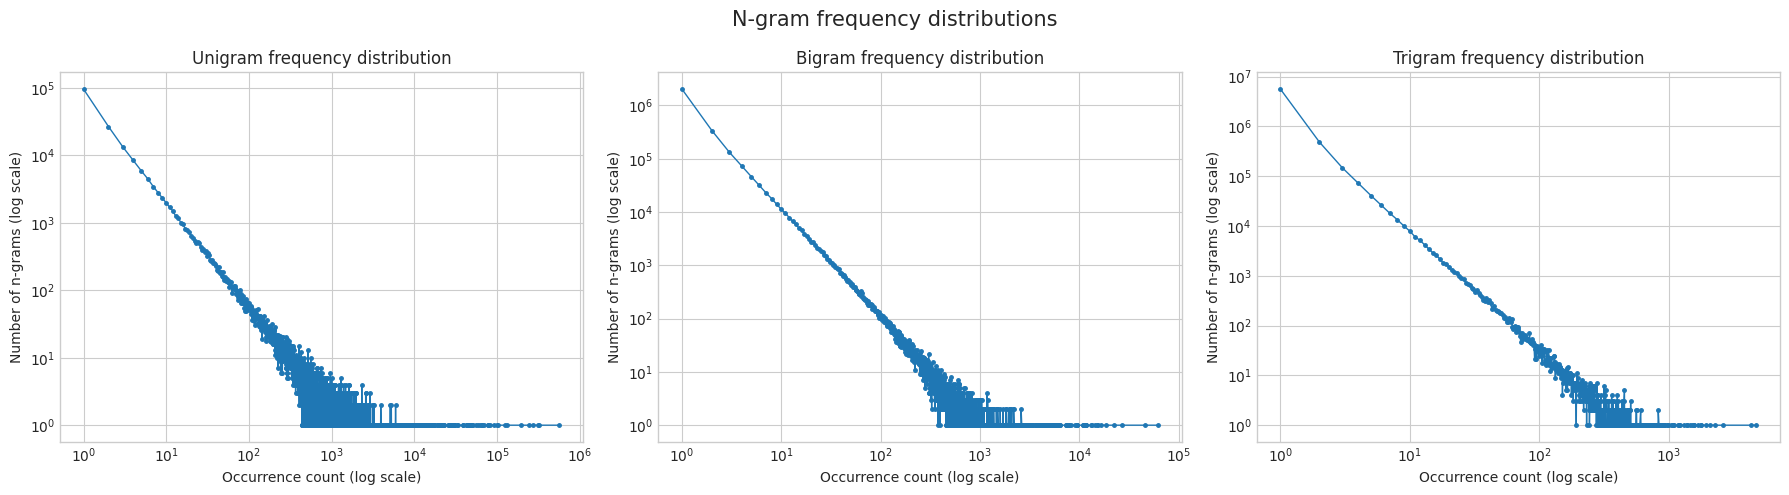

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (model_name, distribution) in zip(axes, frequency_distributions.items()):
    x = distribution['Occurrence count'].to_numpy()
    y = distribution['Number of n-grams'].to_numpy()
    axis.plot(x, y, marker='.', linewidth=1, markersize=5)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.set_title(f'{model_name} frequency distribution')
    axis.set_xlabel('Occurrence count (log scale)')
    axis.set_ylabel('Number of n-grams (log scale)')

fig.suptitle('N-gram frequency distributions', fontsize=15)
fig.tight_layout()
plt.show()

## 9. Discussion and observations

- **Vocabulary size:** vocabulary đếm các từ đơn khác nhau. Khi chuyển từ unigram sang bigram/trigram, các token gốc không đổi; chỉ cách ghép token thành đơn vị n-gram thay đổi.
- **Unique n-grams:** n càng lớn thì thứ tự và tổ hợp token càng cụ thể, nên thường xuất hiện nhiều loại chuỗi khác nhau hơn trong corpus. Hãy dùng bảng kết quả ở trên để kiểm tra xu hướng trên dữ liệu này.
- **Sparsity của trigram:** nhiều trigram chỉ xuất hiện một vài lần hoặc chưa xuất hiện, do mỗi trigram cần khớp chính xác ba token liên tiếp. Bigram chỉ cần khớp hai token nên thường có nhiều lần lặp hơn.

> Hãy tự viết nhận xét dựa trên con số và biểu đồ sau khi chạy notebook. Theo W2, phần giải thích kết quả thực nghiệm cần do sinh viên tự thực hiện.

### AI assistance statement

W2 yêu cầu khai báo nếu dùng AI hỗ trợ code. Hãy điền trung thực các mục sau trước khi nộp:

- Tool: …
- Purpose: …
- What was generated: …
- What was modified by me: …
- How I ran and verified the notebook: …

# Experiment 2 — MLE vs Laplace Smoothing

So sánh bigram và trigram khi dùng Maximum Likelihood Estimation (MLE) và Laplace (add-one) smoothing. Dữ liệu được chia theo **document** để các câu trong cùng document không bị rơi vào nhiều tập khác nhau. Các câu sau preprocessing ở Experiment 1 được dùng lại.


## 1. Train/Validation/Test split

Xáo trộn document bằng seed cố định rồi chia 70% train, 15% validation, 15% test. Vocabulary và n-gram counts của các model chỉ được học từ training set.


In [25]:
import math
import sys

# Thêm thư mục Lab2 để import implementation tự viết.
LAB_DIR = DATA_PATH.parent
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from ngram_lm import NGramLanguageModel

# Seed cố định giúp lần chạy sau có cùng cách chia dữ liệu.
RANDOM_SEED = 42
random_generator = np.random.default_rng(RANDOM_SEED)
shuffled_indices = random_generator.permutation(number_of_documents)

train_end = int(0.70 * number_of_documents)
validation_end = int(0.85 * number_of_documents)

train_indices = shuffled_indices[:train_end]
validation_indices = shuffled_indices[train_end:validation_end]
test_indices = shuffled_indices[validation_end:]

# Giữ các câu đã token hóa, nhưng chia theo document.
train_sentences = [
    sentence
    for index in train_indices
    for sentence in tokenized_documents[index]
]
validation_sentences = [
    sentence
    for index in validation_indices
    for sentence in tokenized_documents[index]
]
test_sentences = [
    sentence
    for index in test_indices
    for sentence in tokenized_documents[index]
]

split_summary = pd.DataFrame([
    {"Split": "Train", "Documents": len(train_indices), "Sentences": len(train_sentences)},
    {"Split": "Validation", "Documents": len(validation_indices), "Sentences": len(validation_sentences)},
    {"Split": "Test", "Documents": len(test_indices), "Sentences": len(test_sentences)},
])
display(split_summary)


,Split,Documents,Sentences
0,Train,21000,444977
1,Validation,4500,93149
2,Test,4500,96815


## 2. Train Bigram and Trigram models

Khởi tạo riêng từng model: n=2 là bigram, n=3 là trigram; smoothing nhận mle hoặc laplace. Laplace dùng vocabulary của training set và thêm token <unk> để ánh xạ từ chưa gặp trong train. MLE vẫn cho xác suất 0 với n-gram chưa thấy.


In [26]:
model_settings = [
    ("Bigram MLE", 2, "mle"),
    ("Bigram Laplace", 2, "laplace"),
    ("Trigram MLE", 3, "mle"),
    ("Trigram Laplace", 3, "laplace"),
]


## 3. Calculate perplexity

Perplexity được tính trên cùng cách token hóa cho train, validation và test. Nếu bất kỳ token nào có xác suất 0, log probability của tập là -inf và perplexity là vô hạn. Với Laplace, từ ngoài vocabulary được ánh xạ thành <unk>.


In [27]:
def calculate_perplexity(model, sentences):
    # PPL = exp(-tổng log probability / tổng số token).
    total_log_probability = 0.0
    total_tokens = 0

    for sentence in sentences:
        total_log_probability += model.sentence_log_probability(sentence)
        total_tokens += len(sentence)

    if total_tokens == 0:
        return math.nan

    if total_log_probability == -math.inf:
        return math.inf

    return math.exp(-total_log_probability / total_tokens)


result_rows = []

# Huấn luyện tuần tự để không giữ cả bốn bộ đếm lớn trong bộ nhớ cùng lúc.
for model_name, n, smoothing in model_settings:
    model = NGramLanguageModel(n=n, smoothing=smoothing)
    model.fit(train_sentences)

    result_rows.append({
        "Model": model_name,
        "Train_PPL": calculate_perplexity(model, train_sentences),
        "Valid_PPL": calculate_perplexity(model, validation_sentences),
        "Test_PPL": calculate_perplexity(model, test_sentences),
    })

    print(f"Đã huấn luyện và đánh giá: {model_name}")
    del model


Đã huấn luyện và đánh giá: Bigram MLE
Đã huấn luyện và đánh giá: Bigram Laplace
Đã huấn luyện và đánh giá: Trigram MLE
Đã huấn luyện và đánh giá: Trigram Laplace


## 4. Results table

Bảng dưới đây và file results.csv chứa perplexity trên cả ba split. Giá trị inf ở MLE cho biết có ít nhất một token trong tập đánh giá nhận xác suất 0.


In [28]:
results_df = pd.DataFrame(
    result_rows,
    columns=["Model", "Train_PPL", "Valid_PPL", "Test_PPL"],
)

display(results_df.round(4))

RESULTS_PATH = LAB_DIR / "results.csv"
results_df.to_csv(RESULTS_PATH, index=False)
print(f"Đã lưu kết quả tại: {RESULTS_PATH}")


,Model,Train_PPL,Valid_PPL,Test_PPL
0,Bigram MLE,186.2617,inf,inf
1,Bigram Laplace,6375.2000,8273.8310,8428.3619
2,Trigram MLE,15.6494,inf,inf
3,Trigram Laplace,30448.5375,50185.0326,50714.7080


Đã lưu kết quả tại: /home/nguyenducthang/NLP/Lab2/results.csv


## 5. Discussion

- **MLE và zero probability:** MLE chỉ gán xác suất dương cho n-gram đã xuất hiện trong training set. Một n-gram chưa thấy có xác suất 0; chỉ một xác suất như vậy cũng làm log probability của câu là -inf.
- **Laplace smoothing:** cộng 1 vào count của từng lựa chọn trong vocabulary, nên cả n-gram chưa quan sát cũng có xác suất dương. Phần xác suất được phân bổ lại cho toàn bộ vocabulary, vì vậy xác suất của n-gram đã thấy cũng thay đổi.
- **Perplexity:** smoothing có thể làm perplexity giảm nếu giúp model dự đoán dữ liệu chưa thấy tốt hơn, nhưng cũng có thể làm tăng perplexity nếu xác suất bị phân tán quá nhiều. Hãy đối chiếu các con số trong bảng, không mặc định một phương pháp luôn tốt hơn.
- **Trigram và sparsity:** trigram cần khớp chính xác hai từ context và từ tiếp theo, nên cùng lượng dữ liệu thường có ít lần lặp trên mỗi context hơn bigram.
- **Train và test:** model được fit trên train nên các n-gram của train đã được quan sát; validation/test chứa các documents khác và có thể có nhiều tổ hợp từ mới. Do đó train perplexity và test perplexity có thể khác nhau.
- **Tự ghi nhận xét từ kết quả:** nêu model nào có Valid_PPL/Test_PPL thấp nhất, MLE có xuất hiện inf không, và so sánh thay đổi từ validation sang test. Theo hướng dẫn W2, phần diễn giải các con số thực nghiệm cần do sinh viên tự hoàn thành.


# Experiment 3 — Perplexity Evaluation

Đánh giá unigram, bigram và trigram trên cùng training, validation và test sets đã tạo ở Experiment 2. Các model dưới đây dùng MLE để so sánh ảnh hưởng của độ dài context. Không dùng thư viện language model có sẵn.


## 1. Load trained models

Bigram và trigram MLE được train trên training set ở cell tính perplexity của Experiment 3 và được giữ lại trong experiment_3_models để dùng tiếp bên dưới. Như vậy Application không tạo hay train thêm model.


In [29]:
# Kiểm tra các tập đã được tạo từ Experiment 2.
print("Train sentences:", len(train_sentences))
print("Validation sentences:", len(validation_sentences))
print("Test sentences:", len(test_sentences))

experiment_3_settings = [
    ("Unigram", 1),
    ("Bigram", 2),
    ("Trigram", 3),
]


Train sentences: 444977
Validation sentences: 93149
Test sentences: 96815


## 2. Calculate perplexity

Dùng lại hàm calculate_perplexity ở Experiment 2. Hàm cộng sentence log probabilities và chia cho tổng số token; nếu một xác suất bằng 0 thì perplexity trả về inf.


In [30]:
experiment_3_rows = []
experiment_3_models = {}

# Giữ lại bigram và trigram đã train để dùng trong Application 1.
for model_name, n in experiment_3_settings:
    model = NGramLanguageModel(n=n, smoothing="mle")
    model.fit(train_sentences)

    train_ppl = calculate_perplexity(model, train_sentences)
    validation_ppl = calculate_perplexity(model, validation_sentences)
    test_ppl = calculate_perplexity(model, test_sentences)

    experiment_3_rows.append({
        "Model": model_name,
        "Train_PPL": train_ppl,
        "Validation_PPL": validation_ppl,
        "Test_PPL": test_ppl,
    })

    # Lưu bigram và trigram; unigram chỉ cần dùng để đánh giá perplexity.
    if n in (2, 3):
        experiment_3_models[model_name] = model
    else:
        del model

    print(
        f"{model_name}: "
        f"Train PPL={train_ppl}, "
        f"Validation PPL={validation_ppl}, "
        f"Test PPL={test_ppl}"
    )


Unigram: Train PPL=2139.92197910549, Validation PPL=inf, Test PPL=inf
Bigram: Train PPL=186.26172274872752, Validation PPL=inf, Test PPL=inf
Trigram: Train PPL=15.649359092181625, Validation PPL=inf, Test PPL=inf


## 3. Results table

Bảng này dùng cùng các split và cách token hóa để so sánh ba model. CSV được lưu trong thư mục Lab2 cạnh dataset.


In [31]:
experiment_3_results = pd.DataFrame(
    experiment_3_rows,
    columns=["Model", "Train_PPL", "Validation_PPL", "Test_PPL"],
)

display(experiment_3_results.round(4))

# Lưu kết quả Experiment 3 theo đúng các cột yêu cầu.
RESULTS_PATH = LAB_DIR / "results.csv"
experiment_3_results.to_csv(RESULTS_PATH, index=False)
print(f"Đã lưu kết quả tại: {RESULTS_PATH}")


,Model,Train_PPL,Validation_PPL,Test_PPL
0,Unigram,2139.9220,inf,inf
1,Bigram,186.2617,inf,inf
2,Trigram,15.6494,inf,inf


Đã lưu kết quả tại: /home/nguyenducthang/NLP/Lab2/results.csv


## 4. Visualization

Biểu đồ thứ nhất so sánh training perplexity; biểu đồ thứ hai so sánh validation và test perplexity. Giá trị inf được hiển thị trong bảng, còn trên biểu đồ được bỏ qua vì không nằm trong miền hữu hạn.


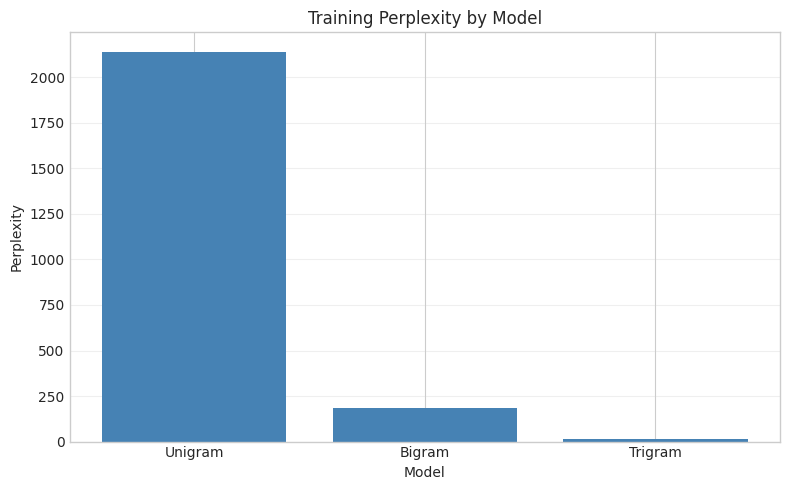

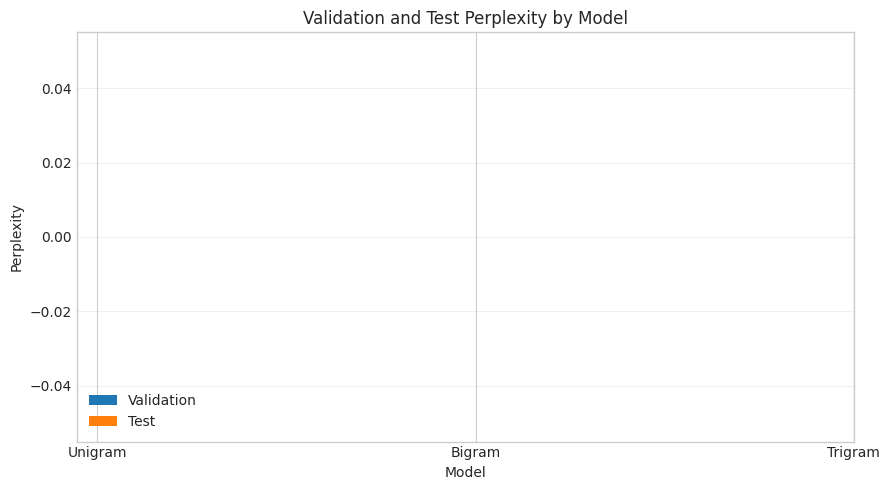

In [32]:
model_names = experiment_3_results["Model"].tolist()
x_positions = np.arange(len(model_names))

# Biểu đồ training perplexity.
train_values = experiment_3_results["Train_PPL"].to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_positions, train_values, color="steelblue")
ax.set_xticks(x_positions, model_names)
ax.set_xlabel("Model")
ax.set_ylabel("Perplexity")
ax.set_title("Training Perplexity by Model")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Biểu đồ validation và test; inf chuyển thành NaN chỉ để không vẽ điểm vô hạn.
validation_values = experiment_3_results["Validation_PPL"].to_numpy(dtype=float)
test_values = experiment_3_results["Test_PPL"].to_numpy(dtype=float)
validation_plot_values = np.where(np.isfinite(validation_values), validation_values, np.nan)
test_plot_values = np.where(np.isfinite(test_values), test_values, np.nan)

width = 0.36
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_positions - width / 2, validation_plot_values, width, label="Validation")
ax.bar(x_positions + width / 2, test_plot_values, width, label="Test")
ax.set_xticks(x_positions, model_names)
ax.set_xlabel("Model")
ax.set_ylabel("Perplexity")
ax.set_title("Validation and Test Perplexity by Model")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


## 5. Discussion

- **Training perplexity:** khi tăng n, model dùng context dài hơn và có thể mô hình hóa các pattern cụ thể hơn trong training data. Hãy xem giá trị thực tế để mô tả xu hướng trong lần chạy này.
- **Validation/test:** context dài hơn làm số tổ hợp có thể có tăng nhanh. Nhiều bigram/trigram có thể chưa xuất hiện trong train, nên model MLE có thể gặp xác suất 0 hoặc không tổng quát tốt trên dữ liệu mới.
- **Overfitting:** một dấu hiệu có thể là training perplexity giảm nhưng validation/test perplexity không giảm hoặc tăng. So sánh ba cột thay vì kết luận chỉ từ training.
- **Corpus size:** corpus lớn thường cung cấp thêm mẫu để quan sát các context dài. Corpus nhỏ khiến trigram dễ thưa và gặp unseen n-gram hơn.
- **Tự ghi nhận kết quả:** viết nhận xét dựa trên bảng và biểu đồ vừa tạo. Theo hướng dẫn W2, phần diễn giải kết quả thực nghiệm cần do sinh viên tự hoàn thành.


# Application 1 — Next-word Prediction

Dùng bigram và trigram MLE đã train ở Experiment 3 để xếp hạng các từ có thể theo sau context. Trigram được ưu tiên vì dùng hai từ context; nếu trigram chưa thấy context đó, dùng bigram làm fallback.


## Load model

Lấy các model đã train trong Experiment 3. Không tạo model mới ở phần Application này.


In [33]:
bigram_model = experiment_3_models["Bigram"]
trigram_model = experiment_3_models["Trigram"]

print("Đã nạp bigram và trigram model từ Experiment 3.")


Đã nạp bigram và trigram model từ Experiment 3.


## Predict function

Hàm gọi next_word_distribution(context), sắp xếp xác suất giảm dần và lấy k từ đầu. Nếu trigram không có kết quả cho context, bigram được dùng làm phương án dự phòng.


In [34]:
def predict_next_words(context, k=3):
    # Hàm này trả về các từ có khả năng xuất hiện tiếp theo cao nhất.
    distribution = trigram_model.next_word_distribution(context)

    if not distribution:
        # Nếu chưa thấy context trigram, thử dự đoán theo bigram.
        distribution = bigram_model.next_word_distribution(context)

    sorted_words = sorted(
        distribution.items(),
        key=lambda item: item[1],
        reverse=True,
    )
    return sorted_words[:k]


## Test 5 contexts

Actual next word được tìm trong test set. Nếu context không xuất hiện trong test set, giá trị sẽ là Unknown.


In [35]:
contexts = [
    "the cat",
    "natural language",
    "machine learning",
    "deep learning",
    "computer vision",
]

def find_actual_next_word(context, sentences):
    # Tìm từ đứng sau context trong các câu của test set.
    context_tokens = WORD_PATTERN.findall(context.lower())

    if not context_tokens:
        return "Unknown"

    context_length = len(context_tokens)
    for sentence in sentences:
        for start in range(len(sentence) - context_length):
            candidate = sentence[start:start + context_length]
            if candidate == context_tokens:
                return sentence[start + context_length]

    return "Unknown"


prediction_rows = []
for context in contexts:
    top_words = predict_next_words(context, k=3)
    prediction_text = (
        ", ".join(f"{word} ({probability:.4f})" for word, probability in top_words)
        if top_words
        else "No prediction"
    )

    prediction_rows.append({
        "Context": context,
        "Prediction": prediction_text,
        "Actual next word": find_actual_next_word(context, test_sentences),
    })


## Results table

In [36]:
prediction_results = pd.DataFrame(
    prediction_rows,
    columns=["Context", "Prediction", "Actual next word"],
)
display(prediction_results)


,Context,Prediction,Actual next word
0,the cat,"queen (0.0980), box (0.0784), and (0.0392)",in
1,natural language,"laboratory (0.3750), processing (0.2500), 1980 (0.1250)",processing
2,machine learning,"and (0.1020), algorithms (0.0816), algorithm (0.0612)",and
3,deep learning,"can (0.1538), ai (0.0769), algorithm (0.0769)",Unknown
4,computer vision,"algorithms (0.2500), and (0.2500), practitioners (0.2500)",based


### Probability chart

Biểu đồ dưới đây hiển thị top 3 từ dự đoán cho context the cat.


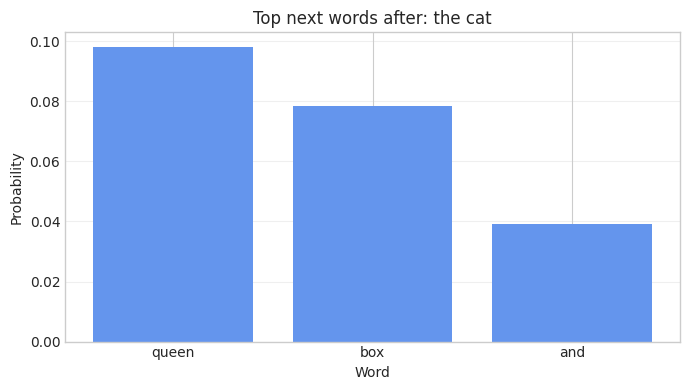

In [37]:
chart_context = "the cat"
chart_predictions = predict_next_words(chart_context, k=3)

if chart_predictions:
    chart_words = [word for word, probability in chart_predictions]
    chart_probabilities = [probability for word, probability in chart_predictions]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(chart_words, chart_probabilities, color="cornflowerblue")
    ax.set_xlabel("Word")
    ax.set_ylabel("Probability")
    ax.set_title(f"Top next words after: {chart_context}")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print(f"Không có dự đoán cho context: {chart_context}")


## Discussion

- Language model ở đây xếp hạng xác suất các từ có thể đứng tiếp theo; nó không tự tạo ra một câu hoàn chỉnh.
- Context dài hơn có thể cung cấp thêm thông tin cho dự đoán. Trigram dùng hai từ trước đó, trong khi bigram chỉ dùng một từ.
- Trigram cũng dễ gặp unseen n-gram hơn, nhất là khi corpus nhỏ. Vì vậy notebook dùng bigram nếu trigram không có dự đoán cho context.
